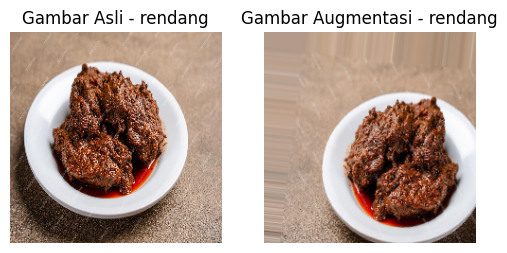

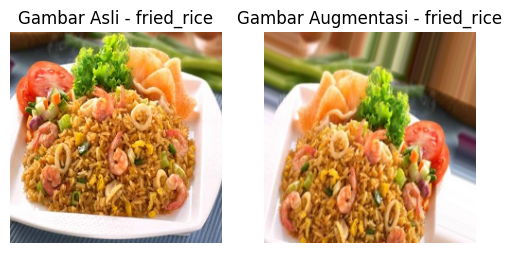

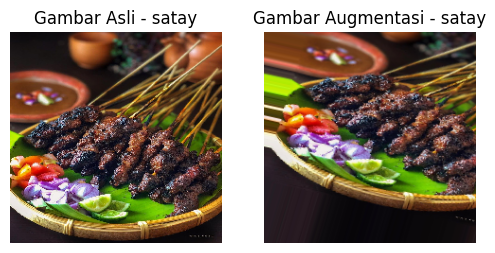

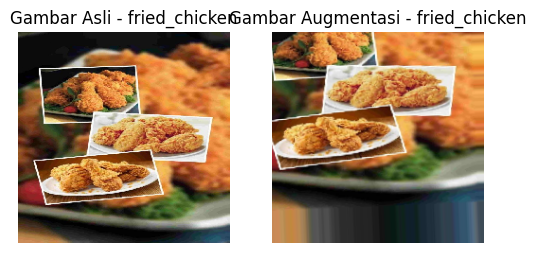

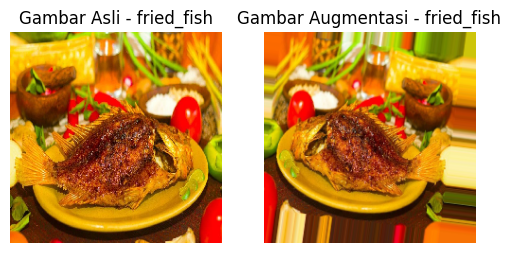

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# Path gambar yang akan diaugmentasi
rendang_path = 'food/rendang/Rendang_006.jpg'  # Ganti dengan path lengkap gambar rendang
fried_rice_path = 'food/fried_rice/Nasi Goreng_005.jpg'  # Ganti dengan path lengkap gambar fried_rice
satay_path = 'food/satay/Sate_008.jpg' 
fried_chicken_path = 'food/fried_chicken/Ayam Goreng_007.jpg' 
fried_fish_path = 'food/fried_fish/Ikan Goreng_011.jpg' 

# Fungsi untuk memuat dan mengubah ukuran gambar menjadi (224, 224)
def load_and_preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Normalisasi
    return img_array

# Muat gambar asli
rendang_image = load_and_preprocess_image(rendang_path)
fried_rice_image = load_and_preprocess_image(fried_rice_path)
satay_image = load_and_preprocess_image(satay_path)
fried_chicken_image = load_and_preprocess_image(fried_chicken_path)
fried_fish_image = load_and_preprocess_image(fried_fish_path)

# Membuat ImageDataGenerator untuk augmentasi
augmentor = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Lakukan augmentasi pada gambar
rendang_augmented = augmentor.flow(rendang_image, batch_size=1)[0]
fried_rice_augmented = augmentor.flow(fried_rice_image, batch_size=1)[0]
satay_augmented = augmentor.flow(satay_image, batch_size=1)[0]
fried_chicken_augmented = augmentor.flow(fried_chicken_image, batch_size=1)[0]
fried_fish_augmented = augmentor.flow(fried_fish_image, batch_size=1)[0]

# Fungsi untuk menampilkan gambar original dan augmented
def show_images(original_img, augmented_img, class_name):
    plt.figure(figsize=(6, 6))
    
    # Tampilkan gambar original
    plt.subplot(1, 2, 1)
    plt.imshow(original_img[0])
    plt.title(f"Gambar Asli - {class_name}")
    plt.axis('off')

    # Tampilkan gambar augmented
    plt.subplot(1, 2, 2)
    plt.imshow(augmented_img[0])
    plt.title(f"Gambar Augmentasi - {class_name}")
    plt.axis('off')

    plt.show()

# Tampilkan gambar rendang dan fried_rice sebelum dan sesudah augmentasi
show_images(rendang_image, rendang_augmented, "rendang")
show_images(fried_rice_image, fried_rice_augmented, "fried_rice")
show_images(satay_image, satay_augmented, "satay")
show_images(fried_chicken_image, fried_chicken_augmented, "fried_chicken")
show_images(fried_fish_image, fried_fish_augmented, "fried_fish")